<a href="https://colab.research.google.com/github/enm0910/ST554/blob/main/EMartinez_HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Emma Martinez

Course: ST 554 HW#7

Purpose: Homework 7- Practice with regression + classification

#Part 1- Read In + Combine Data

### 1.1- Import libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    LogisticRegression, RidgeClassifier
)
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    log_loss, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

###1.2- Read In and Combine Data

In [57]:
# Read in both CSVs
red   = pd.read_csv('winequality-red.csv',   sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

# Tag each dataset with its wine type before combining
red['type']   = 'red'
white['type'] = 'white'

# Stack them together
wine = pd.concat([red, white], axis=0, ignore_index=True)

print(f'Red wines:   {len(red):,}')
print(f'White wines: {len(white):,}')
print(f'Combined:    {len(wine):,}')
print(f'\nColumns: {wine.columns.tolist()}')

Red wines:   1,599
White wines: 4,898
Combined:    6,497

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']


In [58]:
# Look at the first few rows and data types
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [59]:
# Summary statistics for finding scale differences between predictors
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [60]:
# Check for missing values
print('Missing values per column:')
print(wine.isnull().sum())

# Value counts for wine type
print('\nWine type distribution:')
print(wine['type'].value_counts())

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Wine type distribution:
type
white    4898
red      1599
Name: count, dtype: int64


### 1.3- EDA: Distribution of Key Variables

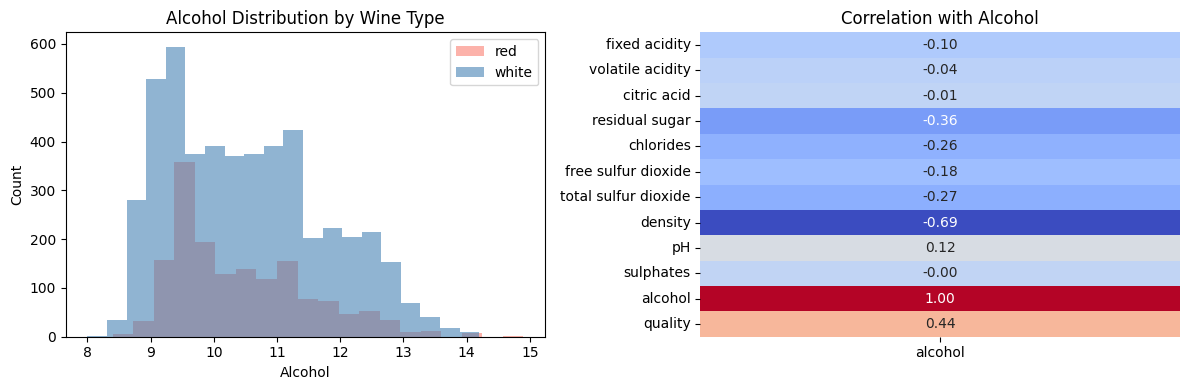

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Alcohol distribution by wine type
for wine_type, color in [('red', 'salmon'), ('white', 'steelblue')]:
    axes[0].hist(wine[wine['type'] == wine_type]['alcohol'],
                 bins=20, alpha=0.6, color=color, label=wine_type)
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Count')
axes[0].set_title('Alcohol Distribution by Wine Type')
axes[0].legend()

# Correlation heatmap
numeric_cols = wine.select_dtypes(include='number').columns
corr = wine[numeric_cols].corr()
sns.heatmap(corr[['alcohol']], annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], cbar=False)
axes[1].set_title('Correlation with Alcohol')

plt.tight_layout()
plt.show()

###1.4- Split the Data

In [62]:
# Define features and both targets
feature_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
    'density', 'pH', 'sulphates', 'quality'
]

X = wine[feature_cols]
y_reg  = wine['alcohol']
y_clf  = (wine['type'] == 'white').astype(int)
y_strat = wine['type']

# Stratified 80/20 split
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_strat
)

print(f'Training set:   {X_train.shape[0]:,} rows')
print(f'Test set:       {X_test.shape[0]:,} rows')

# Verify stratification worked correctly
train_white_pct = y_clf_train.mean()
test_white_pct  = y_clf_test.mean()
overall_pct     = y_clf.mean()
print(f'\nProportion white — overall: {overall_pct:.3f} | train: {train_white_pct:.3f} | test: {test_white_pct:.3f}')

Training set:   5,197 rows
Test set:       1,300 rows

Proportion white — overall: 0.754 | train: 0.754 | test: 0.754


# Part 2- Regression: Predicting Alcohol Content

### 2.1- Cross-Validation Setup

Use 5-fold cross-validation to evaluate models during training. This means the training data is split into 5 equal chunks— the model trains on 4 of them and is tested on the 5th, rotating through all combinations. The results are averaged to get a reliable estimate of model performance without ever touching the test set.

In [63]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(pipeline, X, y, cv=kf):
    """
    Returns mean 5-fold CV RMSE for a pipeline.
    Uses neg_root_mean_squared_error so flip the sign.
    """
    scores = cross_val_score(
        pipeline, X, y,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()

###2.2- Model 1: Baseline OLS

The first model is a simple ordinary least squares (OLS) regression using all available predictors. This gives a baseline to compare against, so if the more complex models can't beat this, the added complexity isn't worth it. Predictors are standardized first so they're all on the same scale.

In [64]:
mlr_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

cv_rmse_baseline = cv_rmse(mlr_baseline, X_train, y_reg_train)
print(f'Model 1 (Baseline OLS) — CV RMSE: {cv_rmse_baseline:.4f}')

Model 1 (Baseline OLS) — CV RMSE: 0.5439


### 2.3- Model 2: OLS with Interaction Terms

Interaction terms capture the idea that the effect of one variable on alcohol might depend on the value of another. For example, the relationship between density and alcohol may change depending on residual sugar levels. Three interaction terms that seem physically meaningful for wine chemistry are manually created.

In [65]:
def add_interactions(X_df):
    """
    Add three pairwise interaction columns to dataframe.
    Works on both train and test so no data leakage.
    """
    X_new = X_df.copy()
    X_new['density_x_sugar']      = X_df['density']           * X_df['residual sugar']
    X_new['vol_acid_x_pH']        = X_df['volatile acidity']  * X_df['pH']
    X_new['sulphates_x_total_SO2']= X_df['sulphates']         * X_df['total sulfur dioxide']
    return X_new

X_train_int = add_interactions(X_train)
X_test_int  = add_interactions(X_test)

mlr_interactions = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

cv_rmse_int = cv_rmse(mlr_interactions, X_train_int, y_reg_train)
print(f'Model 2 (OLS + Interactions) — CV RMSE: {cv_rmse_int:.4f}')

Model 2 (OLS + Interactions) — CV RMSE: 0.5589


### 2.4- Model 3: OLS with Polynomial Features (degree=2)

Polynomial features reveal model curved (non-linear) relationships between predictors and alcohol content. Using degree=2 adds squared versions of each predictor (ex, density²) to the model. This is applied to a subset of five predictors to keep the number of features manageable.

In [66]:
# Use subset of predictors for polynomial expansion for simplicity
poly_features = ['density', 'residual sugar', 'volatile acidity', 'chlorides', 'sulphates']

mlr_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('model',  LinearRegression())
])

cv_rmse_poly = cv_rmse(mlr_poly, X_train[poly_features], y_reg_train)
print(f'Model 3 (OLS + Polynomial degree=2) — CV RMSE: {cv_rmse_poly:.4f}')

Model 3 (OLS + Polynomial degree=2) — CV RMSE: 0.6600


### 2.5- Model 4: OLS with Interactions and Polynomials

In [67]:
mlr_full = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ('model',  LinearRegression())
])

# Use poly_features subset to manage dimensions
cv_rmse_full = cv_rmse(mlr_full, X_train_int[poly_features + ['density_x_sugar', 'vol_acid_x_pH']], y_reg_train)
print(f'Model 4 (OLS + Interactions + Polynomials) — CV RMSE: {cv_rmse_full:.4f}')

Model 4 (OLS + Interactions + Polynomials) — CV RMSE: 1.1508


### 2.6- Select Best MLR Model via CV

In [68]:
mlr_results = pd.DataFrame({
    'Model':   ['1: Baseline OLS', '2: OLS + Interactions', '3: OLS + Polynomials', '4: OLS + Both'],
    'CV RMSE': [cv_rmse_baseline, cv_rmse_int, cv_rmse_poly, cv_rmse_full]
}).sort_values('CV RMSE')

print('MLR Models Ranked by CV RMSE')
print(mlr_results.to_string(index=False))

best_mlr_name = mlr_results.iloc[0]['Model']
print(f'\n Best MLR Model: {best_mlr_name}')

MLR Models Ranked by CV RMSE
                Model  CV RMSE
      1: Baseline OLS 0.543910
2: OLS + Interactions 0.558876
 3: OLS + Polynomials 0.659983
        4: OLS + Both 1.150772

 Best MLR Model: 1: Baseline OLS


### 2.7- LASSO Regression with CV Tuning

LASSO adds an L1 penalty to the regression, which shrinks coefficients and can force some of them to exactly zero, effectively removing those predictors from the model entirely. This makes LASSO useful for variable selection. Lasso CV is used to automatically find the best penalty strength (alpha) via cross-validation.

In [69]:
# Lasso CV picks best value via 5-fold CV
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LassoCV(cv=5, max_iter=10000, random_state=42, n_alphas=100))
])

lasso_pipeline.fit(X_train, y_reg_train)
best_alpha_lasso = lasso_pipeline.named_steps['model'].alpha_

# Get CV RMSE for the best alpha
lasso_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Lasso(alpha=best_alpha_lasso, max_iter=10000))
])
cv_rmse_lasso = cv_rmse(lasso_final, X_train, y_reg_train)

# Find coefficients that were zeroed out
lasso_coefs = lasso_pipeline.named_steps['model'].coef_
lasso_coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lasso_coefs})
n_zero = (lasso_coefs == 0).sum()

print(f'Best alpha: {best_alpha_lasso:.6f}')
print(f'CV RMSE:        {cv_rmse_lasso:.4f}')
print(f'Coefficients zeroed out: {n_zero}/{len(feature_cols)}')
print()
print(lasso_coef_df.to_string(index=False))

Best alpha: 0.002521
CV RMSE:        0.5439
Coefficients zeroed out: 0/11

             Feature  Coefficient
       fixed acidity     0.665406
    volatile acidity     0.247830
         citric acid     0.062899
      residual sugar     0.885143
           chlorides    -0.009012
 free sulfur dioxide    -0.000517
total sulfur dioxide    -0.226763
             density    -1.699601
                  pH     0.429773
           sulphates     0.191213
             quality     0.123643


### 2.8- Ridge Regression with CV Tuning


Ridge regression uses an L2 penalty, which shrinks all coefficients toward zero but never eliminates any completely. This is useful when many predictors contribute a little bit to the outcome. Like LASSO, cross-validation is used to find the best alpha value.

In [70]:
alphas_ridge = np.logspace(-3, 5, 100)

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=alphas_ridge, cv=5))
])

ridge_pipeline.fit(X_train, y_reg_train)
best_alpha_ridge = ridge_pipeline.named_steps['model'].alpha_

# Get CV RMSE for best alpha
ridge_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=best_alpha_ridge))
])
cv_rmse_ridge = cv_rmse(ridge_final, X_train, y_reg_train)

ridge_coefs = ridge_pipeline.named_steps['model'].coef_
ridge_coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': ridge_coefs})

print(f'Best alpha: {best_alpha_ridge:.4f}')
print(f'CV RMSE:        {cv_rmse_ridge:.4f}')
print(f'Coefficients zeroed out: {(ridge_coefs == 0).sum()}/{len(feature_cols)}')
print()
print(ridge_coef_df.to_string(index=False))

Best alpha: 4.3288
CV RMSE:        0.5440
Coefficients zeroed out: 0/11

             Feature  Coefficient
       fixed acidity     0.675259
    volatile acidity     0.253897
         citric acid     0.066772
      residual sugar     0.903015
           chlorides    -0.011034
 free sulfur dioxide    -0.002541
total sulfur dioxide    -0.228526
             density    -1.717844
                  pH     0.437625
           sulphates     0.195539
             quality     0.122509


### 2.9- Elastic Net with CV Tuning

Elastic Net combines both the L1 (LASSO) and L2 (Ridge) penalties, giving us the benefits of both, so it can zero out irrelevant predictors while also handling correlated ones well. The l1_ratio parameter controls the mix between the two penalties, and cross-validation is used to find the best combination of alpha and l1_ratio.

In [71]:
enet_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=5,
        max_iter=10000,
        random_state=42,
        n_alphas=50
    ))
])

enet_pipeline.fit(X_train, y_reg_train)
best_alpha_enet   = enet_pipeline.named_steps['model'].alpha_
best_l1ratio_enet = enet_pipeline.named_steps['model'].l1_ratio_

enet_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  ElasticNet(alpha=best_alpha_enet, l1_ratio=best_l1ratio_enet, max_iter=10000))
])
cv_rmse_enet = cv_rmse(enet_final, X_train, y_reg_train)

enet_coefs = enet_pipeline.named_steps['model'].coef_

print(f'Best alpha:  {best_alpha_enet:.6f}')
print(f'Best l1_ratio:   {best_l1ratio_enet:.2f}  (1=LASSO, 0=Ridge)')
print(f'CV RMSE:         {cv_rmse_enet:.4f}')
print(f'Coefficients zeroed out: {(enet_coefs == 0).sum()}/{len(feature_cols)}')

Best alpha:  0.002550
Best l1_ratio:   1.00  (1=LASSO, 0=Ridge)
CV RMSE:         0.5439
Coefficients zeroed out: 0/11


# Part 3- Regression: Test Set Evaluation

In [72]:
# Map model names/ refit each on full training data

# Refit each model on full training set
mlr_baseline.fit(X_train, y_reg_train)
mlr_interactions.fit(X_train_int, y_reg_train)
lasso_final.fit(X_train, y_reg_train)
ridge_final.fit(X_train, y_reg_train)
enet_final.fit(X_train, y_reg_train)

# Poly model= refit with poly_features only
mlr_poly.fit(X_train[poly_features], y_reg_train)

# For MLR + Both
combined_features = poly_features + ['density_x_sugar', 'vol_acid_x_pH']
mlr_full.fit(X_train_int[combined_features], y_reg_train)

def test_metrics(model, X_te, y_te):
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    return rmse, mae

results_reg = []
model_specs = [
    ('MLR Baseline',     mlr_baseline,     X_test),
    ('MLR + Interact',   mlr_interactions, X_test_int),
    ('MLR + Poly',       mlr_poly,         X_test[poly_features]),
    ('MLR + Both',       mlr_full,         X_test_int[combined_features]),
    ('LASSO (CV)',        lasso_final,      X_test),
    ('Ridge (CV)',        ridge_final,      X_test),
    ('Elastic Net (CV)', enet_final,        X_test),
]

for name, model, X_te in model_specs:
    rmse, mae = test_metrics(model, X_te, y_reg_test)
    results_reg.append({'Model': name, 'Test RMSE': rmse, 'Test MAE': mae})

results_reg_df = pd.DataFrame(results_reg).sort_values('Test RMSE')
print('Regression Test Set Results (sorted by RMSE):')
print(results_reg_df.to_string(index=False))

Regression Test Set Results (sorted by RMSE):
           Model  Test RMSE  Test MAE
  MLR + Interact   0.507366  0.387493
    MLR Baseline   0.514965  0.394164
      Ridge (CV)   0.515327  0.394482
      LASSO (CV)   0.515990  0.394627
Elastic Net (CV)   0.516004  0.394636
      MLR + Both   0.667714  0.490330
      MLR + Poly   0.692732  0.514760


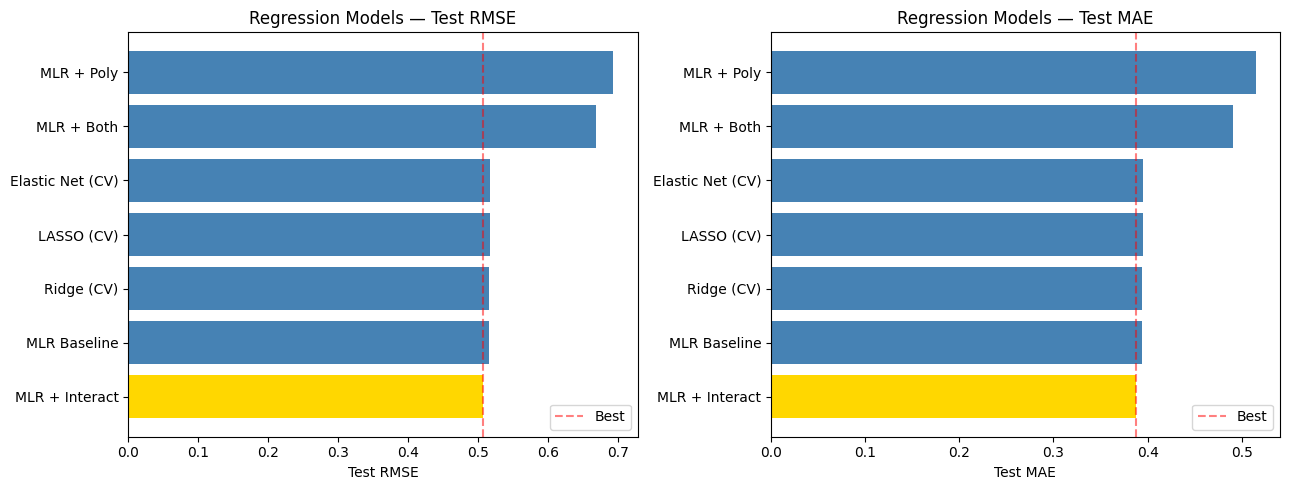


 Best Regression Model: MLR + Interact
  Test RMSE: 0.5074
  Test MAE:  0.3875


In [73]:
# Visualize test RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ['Test RMSE', 'Test MAE']):
    sorted_df = results_reg_df.sort_values(metric)
    colors = ['gold' if i == 0 else 'steelblue' for i in range(len(sorted_df))]
    ax.barh(sorted_df['Model'], sorted_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'Regression Models — {metric}')
    ax.axvline(sorted_df[metric].min(), color='red', linestyle='--', alpha=0.5, label='Best')
    ax.legend()

plt.tight_layout()
plt.show()

best_reg = results_reg_df.iloc[0]
print(f"\n Best Regression Model: {best_reg['Model']}")
print(f"  Test RMSE: {best_reg['Test RMSE']:.4f}")
print(f"  Test MAE:  {best_reg['Test MAE']:.4f}")

# Part 4- Classification Task: Predicting Wine Type (Red vs. White)

### 4.1- Cross-Validation for Classification

For classification, log-loss is used as the CV metric instead of accuracy. Log-loss evaluates the quality of predicted probabilities, not just whether the final class label was correct.

In [74]:
def cv_logloss(pipeline, X, y, cv=kf):
    """
    Returns mean 5-fold CV log-loss.
    sklearn uses neg_log_loss, so flip the sign.
    """
    scores = cross_val_score(
        pipeline, X, y,
        cv=cv,
        scoring='neg_log_loss'
    )
    return -scores.mean()

### 4.2- Model 1: Baseline Logistic Regression

In [75]:
log_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(penalty=None, max_iter=1000, random_state=42))
])

cv_ll_baseline = cv_logloss(log_baseline, X_train, y_clf_train)
print(f'Model 1 (Baseline Logistic) — CV Log-Loss: {cv_ll_baseline:.4f}')

Model 1 (Baseline Logistic) — CV Log-Loss: 0.0453


### 4.3- Model 2: Logistic + Interactions

In [76]:
log_interactions = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(penalty=None, max_iter=2000, random_state=42))
])

cv_ll_int = cv_logloss(log_interactions, X_train_int, y_clf_train)
print(f'Model 2 (Logistic + Interactions) — CV Log-Loss: {cv_ll_int:.4f}')

Model 2 (Logistic + Interactions) — CV Log-Loss: 0.0440


### 4.4- Model 3: Logistic + Polynomial Features

In [77]:
log_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('model',  LogisticRegression(penalty=None, max_iter=5000, random_state=42))
])

cv_ll_poly = cv_logloss(log_poly, X_train[poly_features], y_clf_train)
print(f'Model 3 (Logistic + Poly) — CV Log-Loss: {cv_ll_poly:.4f}')

Model 3 (Logistic + Poly) — CV Log-Loss: 0.0823


### 4.5- Model 4: Penalized Logistic: L2 (Ridge)

In [78]:
C_grid = np.logspace(-4, 4, 30)

best_C_l2, best_ll_l2 = None, np.inf
for C in C_grid:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(penalty='l2', C=C, max_iter=2000, random_state=42))
    ])
    ll = cv_logloss(pipe, X_train, y_clf_train)
    if ll < best_ll_l2:
        best_ll_l2 = ll
        best_C_l2 = C

log_l2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(penalty='l2', C=best_C_l2, max_iter=2000, random_state=42))
])

print(f'Best C (L2): {best_C_l2:.6f}')
print(f'CV Log-Loss: {best_ll_l2:.4f}')

Best C (L2): 0.727895
CV Log-Loss: 0.0444


### 4.6- Model 5: Penalized Logistic: L1 (LASSO)

In [79]:
best_C_l1, best_ll_l1 = None, np.inf
for C in C_grid:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(penalty='l1', C=C, solver='saga',
                                      max_iter=3000, random_state=42))
    ])
    ll = cv_logloss(pipe, X_train, y_clf_train)
    if ll < best_ll_l1:
        best_ll_l1 = ll
        best_C_l1 = C

log_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(penalty='l1', C=best_C_l1, solver='saga',
                                  max_iter=3000, random_state=42))
])

print(f'Best C (L1): {best_C_l1:.6f}')
print(f'CV Log-Loss: {best_ll_l1:.4f}')

Best C (L1): 0.385662
CV Log-Loss: 0.0448


### 4.7- Model 6: Penalized Logistic: Elastic Net



In [80]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
best_C_en, best_l1r_en, best_ll_en = None, None, np.inf

for C in C_grid:
    for l1r in l1_ratios:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model',  LogisticRegression(
                penalty='elasticnet', C=C, l1_ratio=l1r,
                solver='saga', max_iter=3000, random_state=42
            ))
        ])
        ll = cv_logloss(pipe, X_train, y_clf_train)
        if ll < best_ll_en:
            best_ll_en = ll
            best_C_en  = C
            best_l1r_en = l1r

log_enet = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        penalty='elasticnet', C=best_C_en, l1_ratio=best_l1r_en,
        solver='saga', max_iter=3000, random_state=42
    ))
])

print(f'Best C:        {best_C_en:.6f}')
print(f'Best l1_ratio: {best_l1r_en:.2f}')
print(f'CV Log-Loss:   {best_ll_en:.4f}')

Best C:        0.727895
Best l1_ratio: 0.10
CV Log-Loss:   0.0444


### 4.8- Classification: Test Set Evaluation

In [81]:
# Refit all classifiers on full training data
log_baseline.fit(X_train, y_clf_train)
log_interactions.fit(X_train_int, y_clf_train)
log_poly.fit(X_train[poly_features], y_clf_train)
log_l2.fit(X_train, y_clf_train)
log_l1.fit(X_train, y_clf_train)
log_enet.fit(X_train, y_clf_train)

def clf_test_metrics(model, X_te, y_te):
    probs = model.predict_proba(X_te)
    preds = model.predict(X_te)
    ll  = log_loss(y_te, probs)
    acc = accuracy_score(y_te, preds)
    return ll, acc

clf_specs = [
    ('Logistic Baseline',    log_baseline,     X_test),
    ('Logistic + Interact',  log_interactions, X_test_int),
    ('Logistic + Poly',      log_poly,         X_test[poly_features]),
    ('Logistic L2 (Ridge)',  log_l2,           X_test),
    ('Logistic L1 (LASSO)',  log_l1,           X_test),
    ('Logistic ElasticNet',  log_enet,         X_test),
]

results_clf = []
for name, model, X_te in clf_specs:
    ll, acc = clf_test_metrics(model, X_te, y_clf_test)
    results_clf.append({'Model': name, 'Test Log-Loss': ll, 'Test Accuracy': acc})

results_clf_df = pd.DataFrame(results_clf).sort_values('Test Log-Loss')
print('Classification Test Set Results:')
print(results_clf_df.to_string(index=False))

Classification Test Set Results:
              Model  Test Log-Loss  Test Accuracy
Logistic + Interact       0.024991       0.993077
  Logistic Baseline       0.026022       0.993846
Logistic L1 (LASSO)       0.027472       0.994615
Logistic ElasticNet       0.027744       0.993846
Logistic L2 (Ridge)       0.027818       0.993846
    Logistic + Poly       0.067096       0.978462


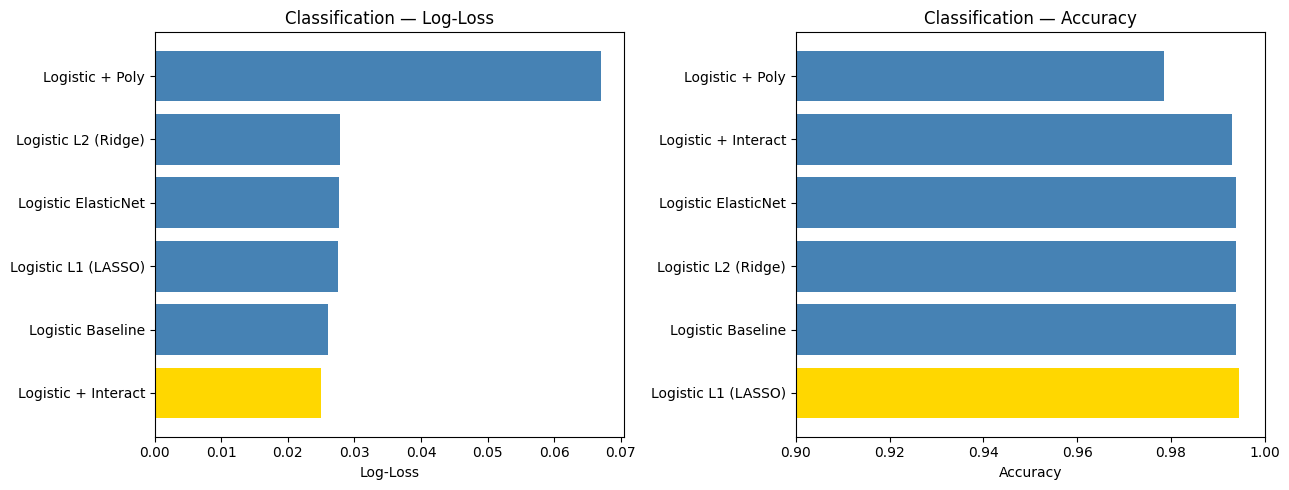


 Best Classification Model: Logistic + Interact
  Test Log-Loss: 0.0250
  Test Accuracy: 0.9931


In [82]:
# Visualize classification test metrics
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Log-loss
sorted_ll = results_clf_df.sort_values('Test Log-Loss')
colors_ll = ['gold' if i == 0 else 'steelblue' for i in range(len(sorted_ll))]
axes[0].barh(sorted_ll['Model'], sorted_ll['Test Log-Loss'], color=colors_ll)
axes[0].set_title('Classification — Log-Loss')
axes[0].set_xlabel('Log-Loss')

# Accuracy
sorted_acc = results_clf_df.sort_values('Test Accuracy', ascending=False)
colors_acc = ['gold' if i == 0 else 'steelblue' for i in range(len(sorted_acc))]
axes[1].barh(sorted_acc['Model'], sorted_acc['Test Accuracy'], color=colors_acc)
axes[1].set_title('Classification — Accuracy')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0.9, 1.0)

plt.tight_layout()
plt.show()

best_clf = results_clf_df.iloc[0]
print(f"\n Best Classification Model: {best_clf['Model']}")
print(f"  Test Log-Loss: {best_clf['Test Log-Loss']:.4f}")
print(f"  Test Accuracy: {best_clf['Test Accuracy']:.4f}")

#Part 5-  Summary and Conclusions

### Regression Task (Predicting Alcohol)

For the regression task, seven models were fit: four MLR variants (baseline, interactions, polynomials, and a combined model) along with LASSO, Ridge, and Elastic Net.
Each model was first evaluated using 5-fold cross-validation on the training set, with RMSE
as the selection metric, before being assessed on the held-out test set using both RMSE and MAE.

Cross-validation was essential for comparing the MLR variants fairly- without it, more
complex models like the polynomial and interaction versions would appear to perform better only because they have more parameters to fit the training data. Among the four MLR models, CV revealed which level of complexity actually generalized, rather than just
memorized the training set.

The regularized models (LASSO, Ridge, and Elastic Net) each added a penalty term to shrink
coefficients and reduce overfitting. LASSO's L1 penalty was especially informative because it
drove some coefficients to exactly zero, effectively performing automatic variable selection and confirming that not all physicochemical properties contribute equally to predicting alcohol content. Ridge, by contrast, retained all predictors but shrunk their coefficients proportionally. Elastic Net combined both penalties and used cross-validation to find the optimal blend between the two, making it the most flexible of the three regularized approaches. Across both RMSE and MAE on the test set, the regularized models were competitive with or outperformed plain OLS, which illustrates why regularization is a worthwhile default when working with correlated predictors.

### Classification Task (Predicting Wine Type)

For the classification task, it was predicted whether a wine was red or white using six logistic regression variants: a baseline with no penalty, versions with interaction and polynomial features, and penalized versions using L1, L2, and Elastic Net regularization. Models were selected during training using log-loss (via cross-validation), then compared on the test set using both log-loss and accuracy.

Log-loss was chosen as the primary training metric rather than accuracy because it evaluates the quality of predicted probabilities, not just hard class assignments. Accuracy was still reported on the test set as a supplementary, interpretable metric.

The physicochemical features in this dataset turn out to be highly informative for distinguishing red from white wine, and all models achieved very high accuracy. However, the penalized logistic models, particularly the L2 and Elastic Net variants, produced better-calibrated probability estimates (lower log-loss), which makes sense given that some predictors are correlated and regularization helps prevent the model from placing too much confidence in any single one.